# Different ways to interpolate the boundary D0

In [1]:
# ADDS THE PARENT DIRECTORY TO SYS.PATH
import sys
import os

# Add the project root directory (one level up) to sys.path
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.append(project_root)

In [2]:
from src.integrator.integrate import phi, phi_inv
import numpy as np
import matplotlib.pyplot as plt

In [3]:
e0 = 0.5
bound_tv = np.load("../boundary_test1/e0_5__v2_eps0_001__deltmax_100.npy")

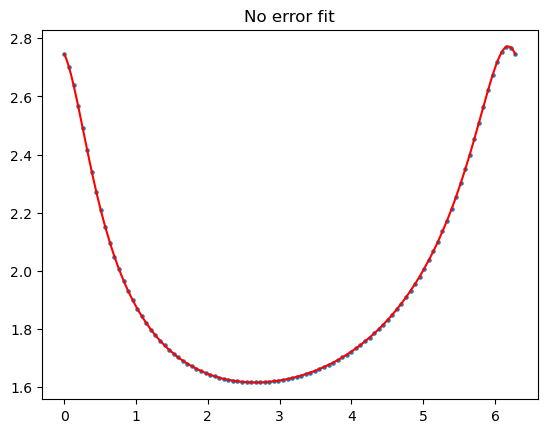

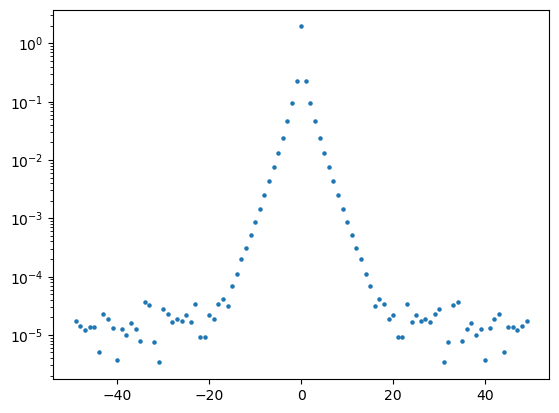

In [39]:
shape = bound_tv[1,:-1].shape
v_data = bound_tv[1,:-1]
t_data = bound_tv[0,:-1]

N = len(v_data)

# Fourier coefficients
c_four = np.fft.fft(v_data) / N

# integer wave numbers: 0,1,...,N/2-1,-N/2,...,-1
k_four = np.fft.fftfreq(N) * N

def interpol_D0_v(t, k_cut = 20):
    t = np.asarray(t) % (2*np.pi)   # enforce periodicity
    i_central = np.abs(k_four) <= k_cut
    phases = np.exp(1j * np.outer(k_four[i_central], t))
    vals = (c_four[i_central, None] * phases).sum(axis=0)
    return vals.real

plt.scatter(bound_tv[0], bound_tv[1], s = 5)
t_val = np.linspace(0, 2*np.pi, 400)
v_val = interpol_D0_v(t_val, k_cut = 49)
plt.plot(t_val, v_val, color = "red")
plt.title("No error fit")
plt.show()

plt.scatter(k_four, np.abs(c_four), s = 5)
plt.yscale("log")

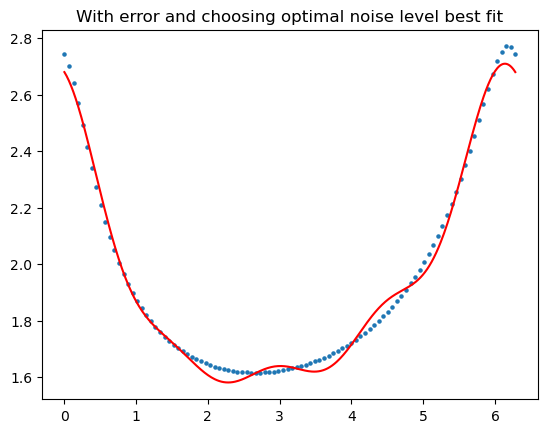

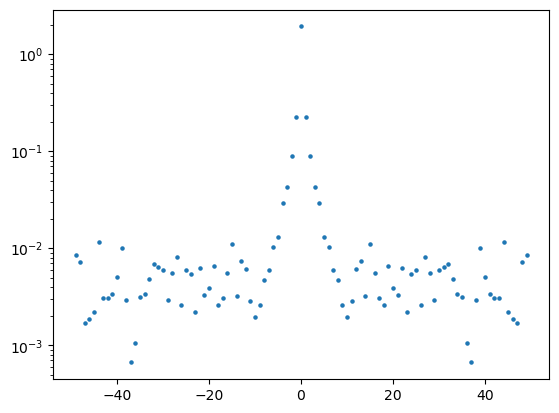

In [46]:
error = 1e-1

shape = bound_tv[1,:-1].shape
v_data = bound_tv[1,:-1] + error*np.random.uniform(-1, 1, shape)
t_data = bound_tv[0,:-1] + error*np.random.uniform(-1, 1, shape)

N = len(v_data)

# Fourier coefficients
c_four = np.fft.fft(v_data) / N

# integer wave numbers: 0,1,...,N/2-1,-N/2,...,-1
k_four = np.fft.fftfreq(N) * N

def interpol_D0_v(t, noise_level):
    t = np.asarray(t) % (2*np.pi)   # enforce periodicity
    i_central = np.abs(c_four) >= noise_level
    phases = np.exp(1j * np.outer(k_four[i_central], t))
    vals = (c_four[i_central, None] * phases).sum(axis=0)
    return vals.real

plt.scatter(bound_tv[0], bound_tv[1], s = 5)
t_val = np.linspace(0, 2*np.pi, 400)
v_val = interpol_D0_v(t_val, noise_level = 1.5e-2)
plt.plot(t_val, v_val, color = "red")
plt.title("With error and choosing optimal noise level best fit")
plt.show()

plt.scatter(k_four, np.abs(c_four), s = 5)
plt.yscale("log")

The conclusion is that including modes at noise level gives a noisy overfit interpolation, but excluding modes under noise level gives a clear underfit, we need lower modes to compensate the exclusion of high modes under noise. 

## Other method

In [47]:
error = 1e-1
K = 6

error = 1e-1

shape = bound_tv[1,:-1].shape
v_data = bound_tv[1,:-1] + error*np.random.uniform(-1, 1, shape)
t_data = bound_tv[0,:-1] + error*np.random.uniform(-1, 1, shape)

In [ ]:
import numpy as np
from numpy.linalg import lstsq
from numpy.linalg import solve

def fourier_design(t, K):
    t = np.asarray(t)
    N = t.size
    X = np.ones((N, 1 + 2*K))
    for k in range(1, K+1):
        X[:, 2*k-1] = np.cos(k * t)
        X[:, 2*k]   = np.sin(k * t)
    return X

# OLS
X = fourier_design(t_data, K)
coef, *_ = lstsq(X, v_data, rcond=None)  # coeff shape (1+2K,)

# # Ridge (lambda > 0)
# lam = 1e-4   # tune this (depends on noise variance)
# A = X.T @ X + lam * np.diag(np.concatenate([[0], np.repeat(1.0, 2*K)]))
# b = X.T @ v_data
# coef_ridge = solve(A, b)
